# Tutorial: CRC Visium HD microarchitecture analysis

This tutorial starts from the per-spot STEP outputs for the CRC Visium HD samples and identifies recurring microarchitectures (MAs) in the tumor periphery. An MA is represented computationally as a local graph centered on a low-coherence spot; graph nodes carry cell-type labels, and recurring graph organization is identified with a Weisfeiler-Lehman graph kernel followed by spectral clustering. The dataset source is listed under Human colorectal cancer in `docs/data_accessions.md`.

The workflow covers five stages:

1. Load the filtered STEP metadata and matching expression matrices.
2. Convert image coordinates to physical microns and construct 50-micron local graphs around low-coherence tumor-periphery spots.
3. Cluster recurring graph structures and summarize each MA.
4. Map MA centers back to the three CRC sections.
5. Characterize MA-specific ligand-receptor programs with CellPhoneDB and BH-FDR correction.

Required metadata columns include `batch`, `domain`, `cell_type`, `cosine`, `x`, and `y`. Paths below are relative to the analysis repository and should be adjusted if the data are stored elsewhere.

**Data source:** Human colorectal cancer Visium HD datasets from [10x Genomics](https://www.10xgenomics.com/resources/datasets).

## 1. Import analysis dependencies

`MicroArc` performs center selection, local graph construction, graph-kernel calculation, MA clustering, and graph summaries. LIANA dependencies are imported later because they are only needed for communication analysis.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.spatial import KDTree, Delaunay
from sklearn.cluster import SpectralClustering
from grakel import WeisfeilerLehman, VertexHistogram
from tqdm import tqdm
from typing import Literal
from collections import Counter

import matplotlib.patches as patches
from matplotlib.patches import ConnectionStyle

from step.models.niche import MicroArc


## 2. Load STEP outputs and expression data

The metadata table contains the domain, spatial-coherence, coordinate, and cell-type results used to define graph centers and node labels. The raw Visium HD objects are loaded separately because the downstream ligand-receptor analysis requires gene-expression values.

In [2]:
# Per-spot STEP annotations retained for the five CRC sections.
metadata = pd.read_csv('./results/visium-hd/crc5_meta_filtered.csv', index_col=0)


In [3]:
import anndata as ad
from pathlib import Path
from step.utils.misc import read_visium_hd


def read_data(name, path):
    """Load one Visium HD section and normalize its spatial-library key."""
    adata = read_visium_hd(path)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    cur_name = list(adata.uns['spatial'].keys())[0]
    adata.uns['spatial'][name] = adata.uns['spatial'].pop(cur_name)
    return adata

crc_ds = {
    'cancer_p1': Path('./data/visium-hd-crc/cancer_p1/binned_outputs/square_008um/'),
    'cancer_p2': Path("./data/visium-hd/human-coloretal-cancer/square_008um/"),
    'cancer_p5': Path('./data/visium-hd-crc/cancer_p5/binned_outputs/square_008um/'),
    'normal_p3': Path('./data/visium-hd-crc/normal_p3/binned_outputs/square_008um/'),
    'normal_p5': Path('./data/visium-hd-crc/normal_p5/binned_outputs/square_008um/'),
}

# Preserve section identity while concatenating all five expression matrices.
adatas = {k: read_data(k, v) for k, v in crc_ds.items()}
adata = ad.concat(adatas, label='batch', uns_merge='unique')

adata.obs.index = adata.obs_names + '-' + adata.obs['batch'].astype(str)
# Restrict the expression object to spots retained in the STEP metadata.
adata = adata[metadata.index]
adata.obs['cell_type'] = metadata['cell_type']

# LIANA is run on library-size-normalized, log-transformed expression.
sc.pp.normalize_total(adata, target_sum=1e5)
sc.pp.log1p(adata)


In [4]:
# Attach all analysis columns to AnnData using the shared spot index.
from step.utils.plotting import spatial_plot

adata.obs[metadata.columns] = metadata
adata.obs['batch'] = adata.obs['batch'].astype('category')
# spatial_plot(adata[adata.obs['domain'].isin([5, 9])], img_key=None, color='cosine', cmap='RdYlGn', size=1., vmax=1, vmin=0.2, )


## 3. Build and cluster low-coherence local graphs

The source metadata stores image-pixel coordinates. Batch-specific `microns_per_pixel` values from the Visium HD spatial metadata convert those coordinates into physical microns before graph construction. Candidate centers are spots assigned to the CRC tumor-periphery domain in cancer sections, and the bottom 20% by spatial coherence are selected as context-discordant centers. Each center and all spots within 50 microns form one labeled graph. The approximate graph-kernel path groups those graphs into three recurring MA classes.


In [5]:
# Convert each section from image pixels to physical microns.
scale_adata = sc.read_h5ad(
    './results/visium-hd/cancer_tumor_regions.h5ad',
    backed='r',
)
try:
    microns_per_pixel = {
        batch: float(payload['scalefactors']['microns_per_pixel'])
        for batch, payload in scale_adata.uns['spatial'].items()
    }
finally:
    scale_adata.file.close()

metadata_um = metadata.copy()
metadata_um['microns_per_pixel'] = metadata_um['batch'].map(microns_per_pixel)
if metadata_um['microns_per_pixel'].isna().any():
    missing = sorted(
        metadata_um.loc[metadata_um['microns_per_pixel'].isna(), 'batch'].unique()
    )
    raise ValueError(f'Missing microns_per_pixel for batches: {missing}')
metadata_um['x_pixel'] = metadata_um['x']
metadata_um['y_pixel'] = metadata_um['y']
metadata_um['x'] = metadata_um['x_pixel'] * metadata_um['microns_per_pixel']
metadata_um['y'] = metadata_um['y_pixel'] * metadata_um['microns_per_pixel']

query = metadata_um[
    metadata_um['domain'].eq(9)
    & metadata_um['batch'].astype(str).str.startswith('cancer')
].index

coherence_threshold = float(metadata_um.loc[query, 'cosine'].quantile(0.20))

niche = MicroArc(
    metadata=metadata_um,
    label_col='cell_type',
    batch_col='batch',
    coherence_threshold=coherence_threshold,
    radius=50.0,
    n_clusters=3,
    n_iter=5,
)
niche.create_graphs(query).compute_kernel_and_cluster(method='approx')
cluster_stats = niche.analyze_patterns()


Found 14554 low coherence centers


Creating graphs for batch cancer_p5: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3789/3789 [00:01<00:00, 2429.46it/s]


Computing graph kernels...


Computing kernel blocks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:39<00:00,  6.60s/it, block=(2,2), size=4554x4554]


Performing clustering...


The kernel matrix below stores pairwise graph similarity. It is exposed here for inspection or downstream diagnostics; MA assignments have already been computed by `compute_kernel_and_cluster`.

In [6]:
km = niche.compute_kernel_matrix()


Computing kernel blocks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:39<00:00,  6.65s/it, block=(2,2), size=4554x4554]


## 4. Inspect and visualize the MA classes

`cluster_stats` summarizes the graph clusters. The first plot shows all MA classes together. The following loops export one average graph per MA, followed by section-specific average graphs. In these API calls, `pattern_idx` is the internal name for an MA-cluster index.

In [9]:
cluster_stats


,cluster,total_niches,cancer_p1_count,cancer_p2_count,cancer_p5_count,cancer_p1_proportion,cancer_p2_proportion,cancer_p5_proportion,pattern_type
0,0,5929,2778,1546,1605,0.451194,0.335503,0.423595,Shared
1,1,4373,2174,1043,1156,0.353094,0.226345,0.305094,Shared
2,2,4252,1205,2019,1028,0.195712,0.438151,0.271312,Shared


Found 5929 cells with pattern 0
Found 5929 cells with pattern 0
Found 5929 cells with pattern 0
Found 5929 cells with pattern 0
Found 4373 cells with pattern 1
Found 4373 cells with pattern 1
Found 4373 cells with pattern 1
Found 4373 cells with pattern 1
Found 4252 cells with pattern 2
Found 4252 cells with pattern 2
Found 4252 cells with pattern 2
Found 4252 cells with pattern 2


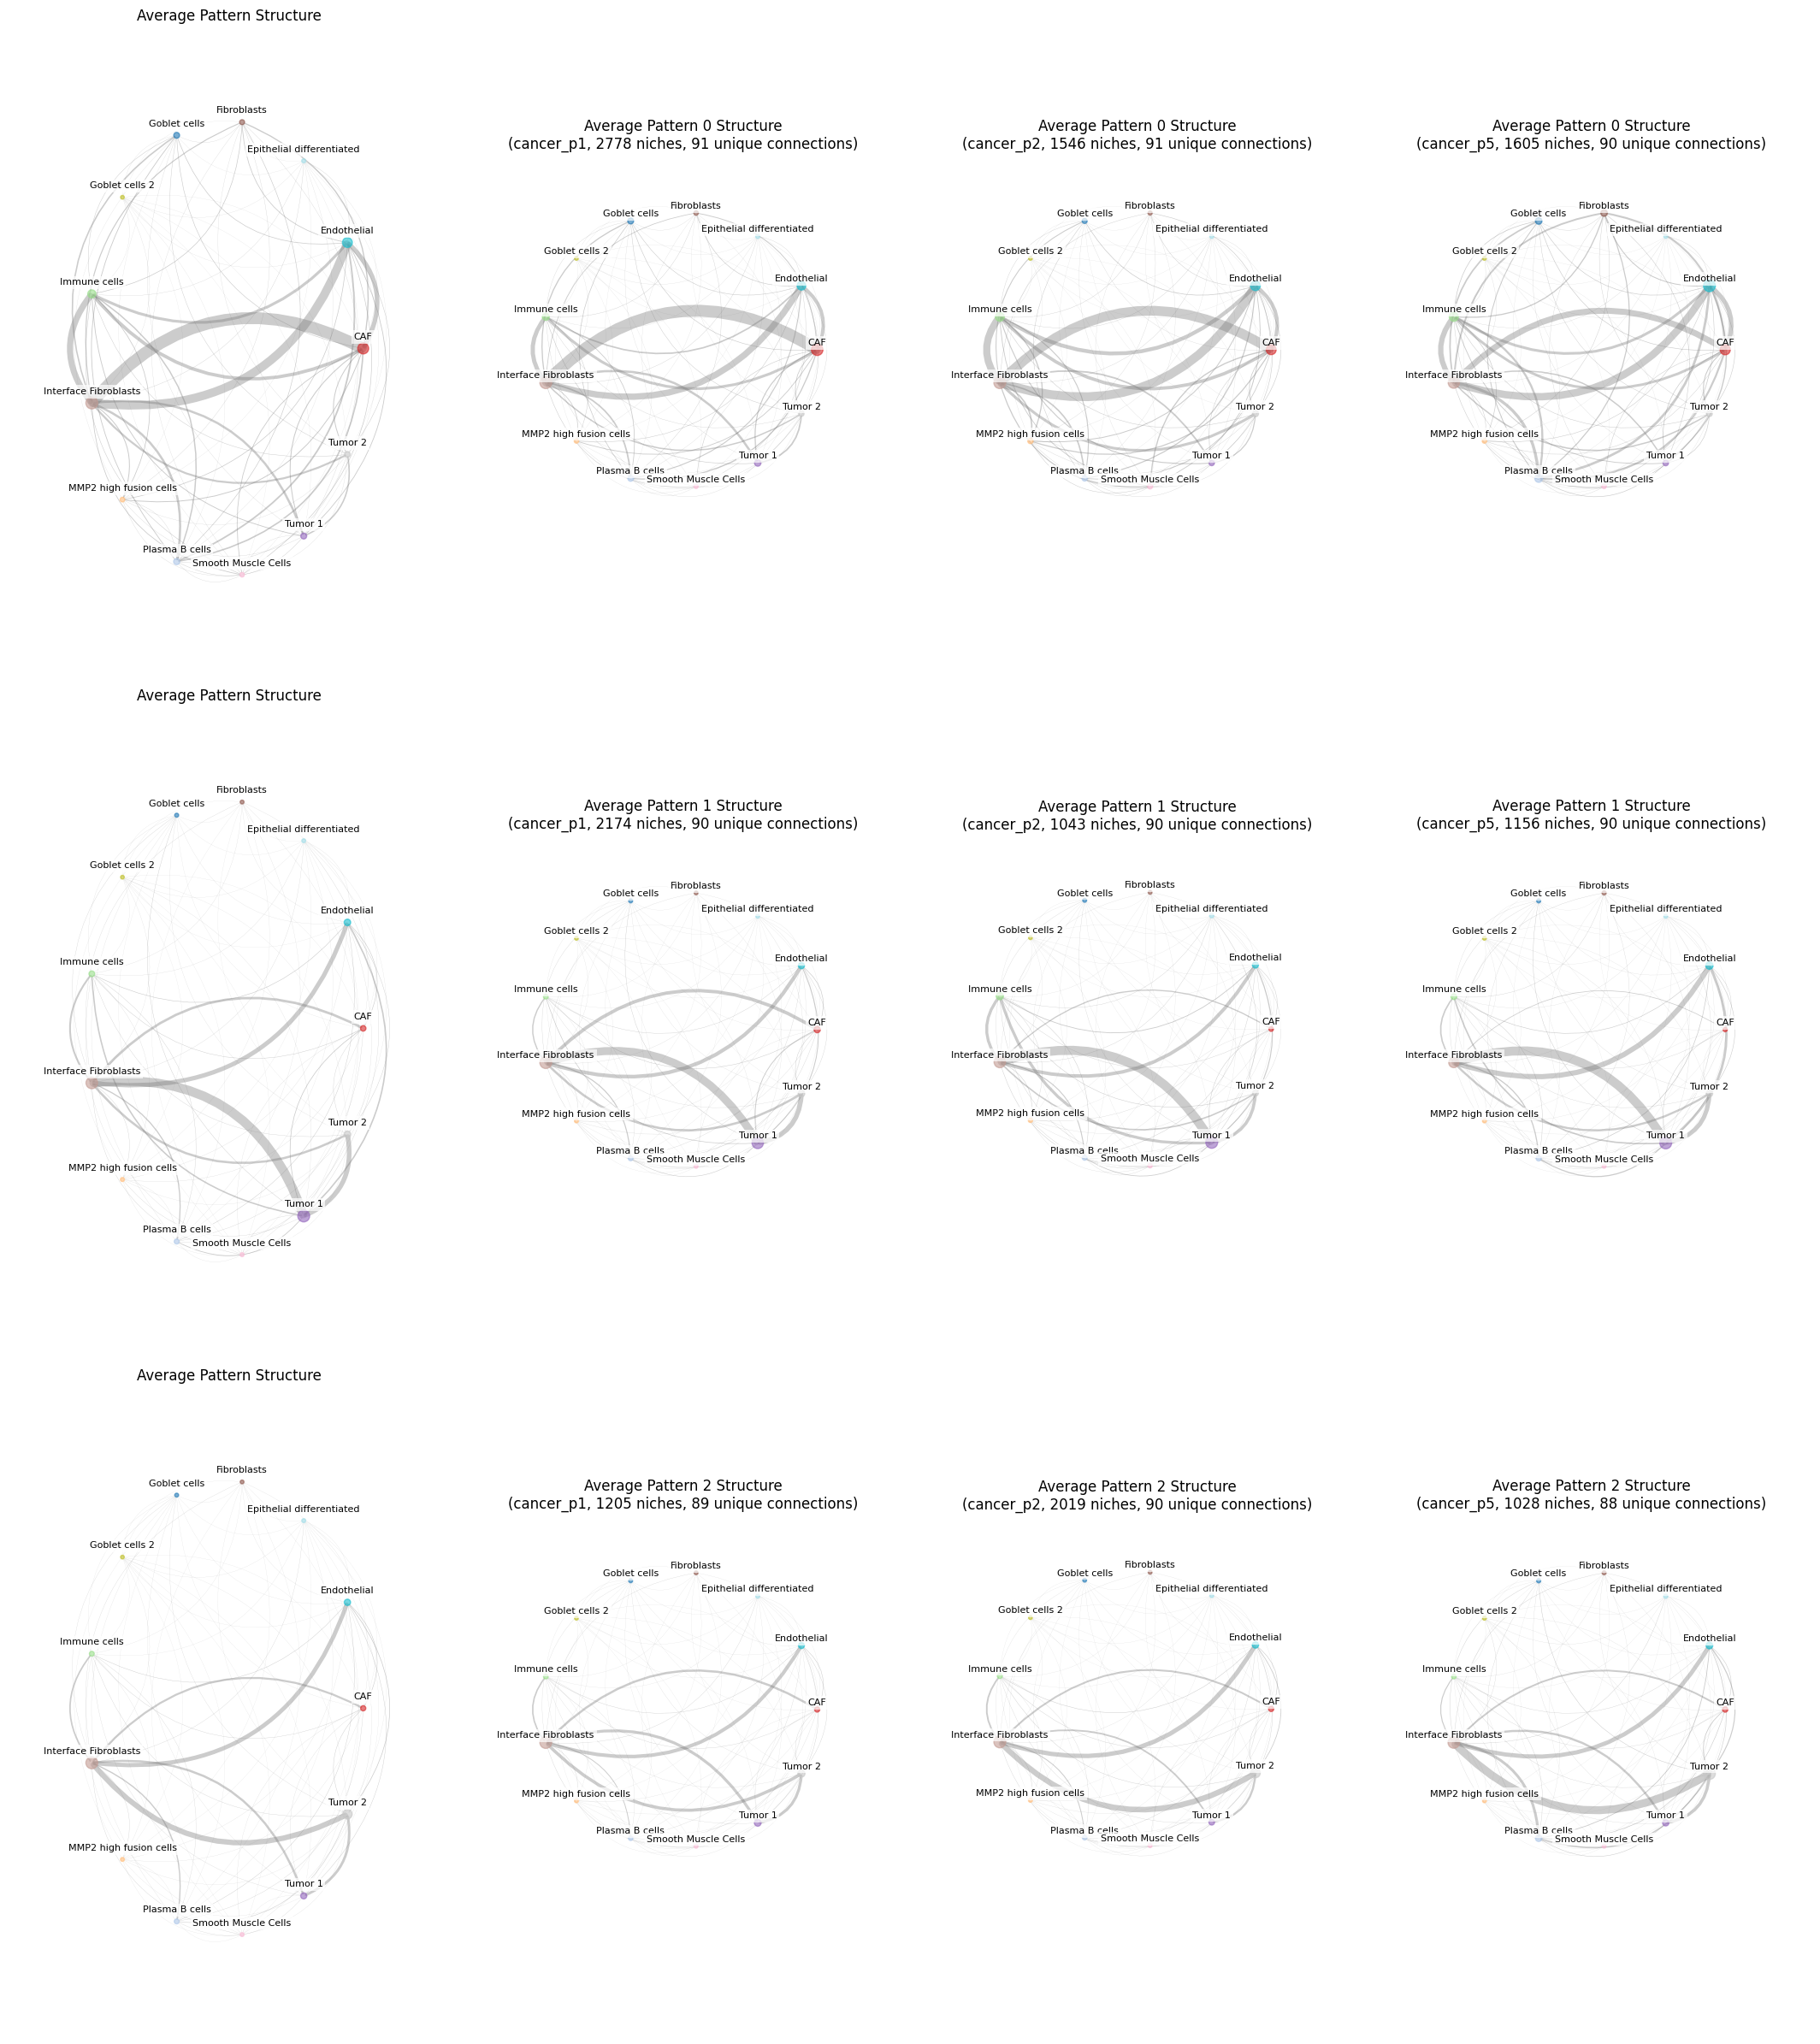

In [11]:
# Compare all recurring MA classes in one graph-summary figure.
niche.plot_patterns(show_edges=True,
                    figsize_multiplier=(24, 8),
                    node_size_range=(10, 100),
                    edge_width_range=(0.1, 10),
                    edge_curve=0.4,
                   )


Found 6440 cells with pattern 0
Found 4912 cells with pattern 1
Found 3202 cells with pattern 2


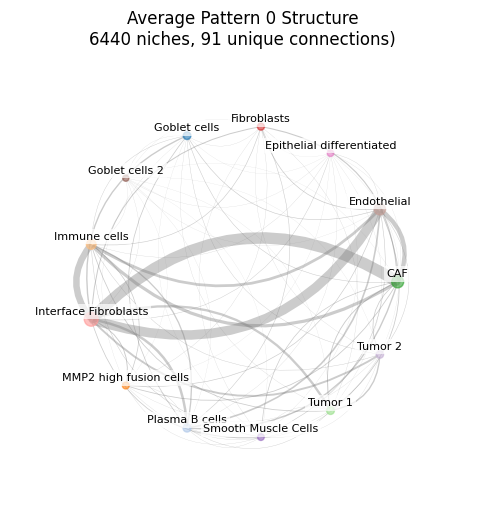

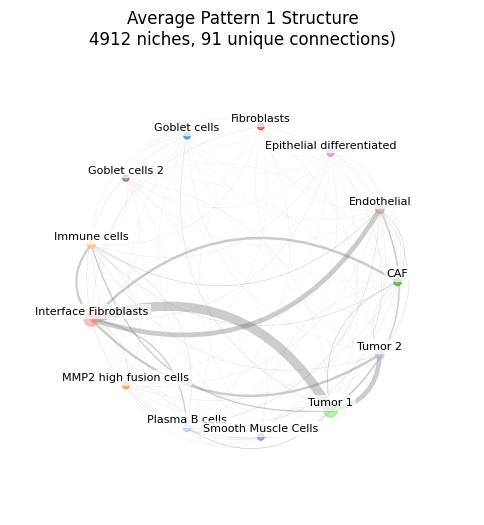

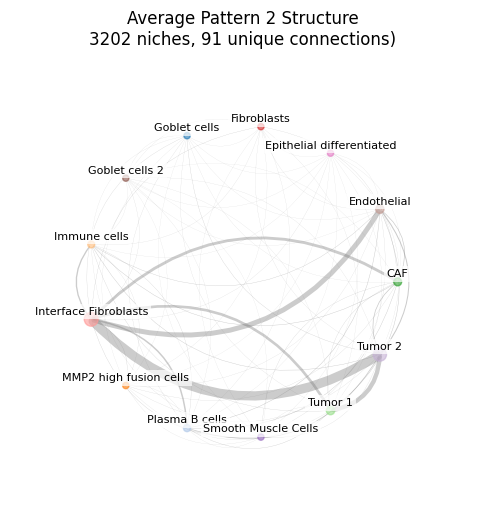

In [10]:
# Export an average graph for each MA across all CRC sections.
for idx in np.unique(niche.clusters):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    niche.get_average_pattern(
        pattern_idx=idx,
        node_size_range=(20, 100),
        edge_width_range=(0.1, 10),
        edge_curve=0.4,
        return_fig=True,
        ax=ax
    )
    fig.savefig(f'./results/visium-hd/microarc_{idx}_aver.pdf', dpi=300)


Found 6440 cells with pattern 0
Found 6440 cells with pattern 0
Found 6440 cells with pattern 0
Found 6440 cells with pattern 0
Found 6440 cells with pattern 0
Found 4912 cells with pattern 1
Found 4912 cells with pattern 1
Found 4912 cells with pattern 1
Found 4912 cells with pattern 1
Found 4912 cells with pattern 1
Found 3202 cells with pattern 2
Found 3202 cells with pattern 2
Found 3202 cells with pattern 2
Found 3202 cells with pattern 2
Found 3202 cells with pattern 2


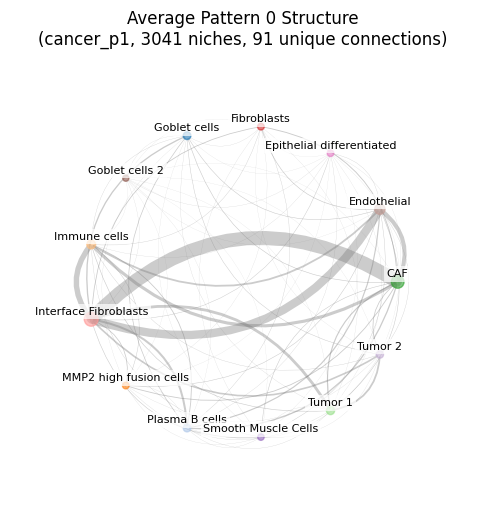

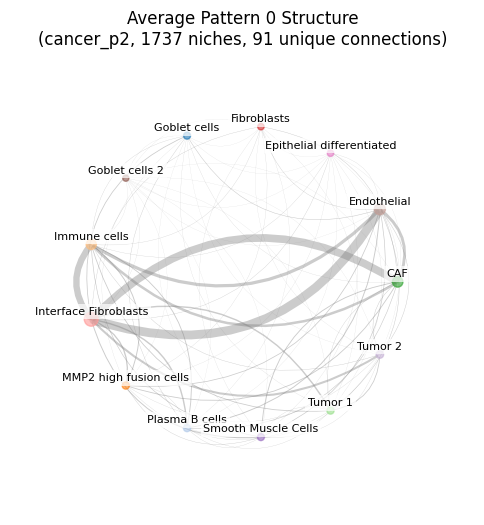

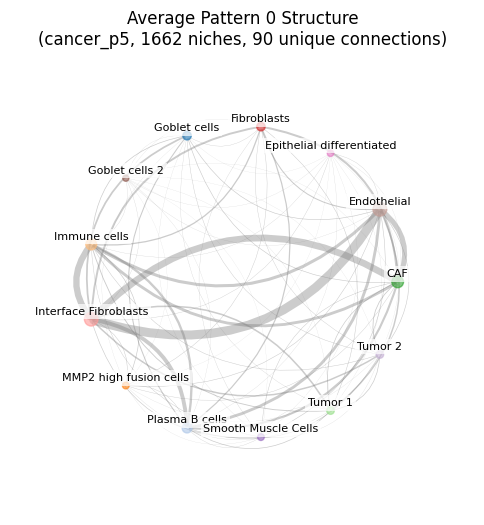

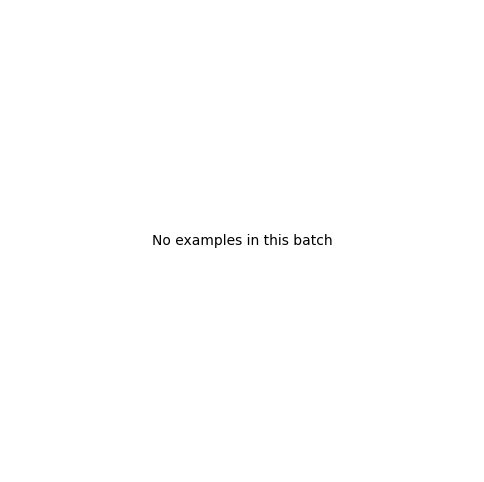

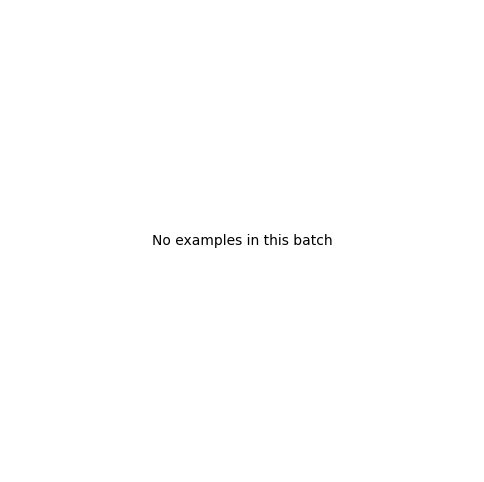

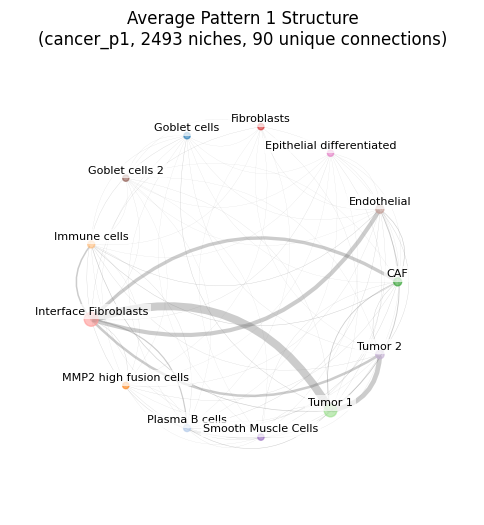

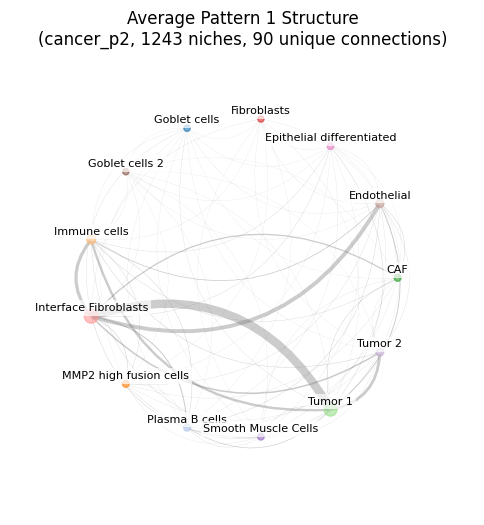

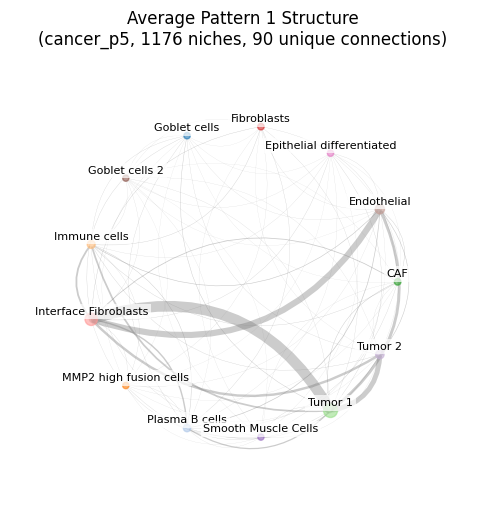

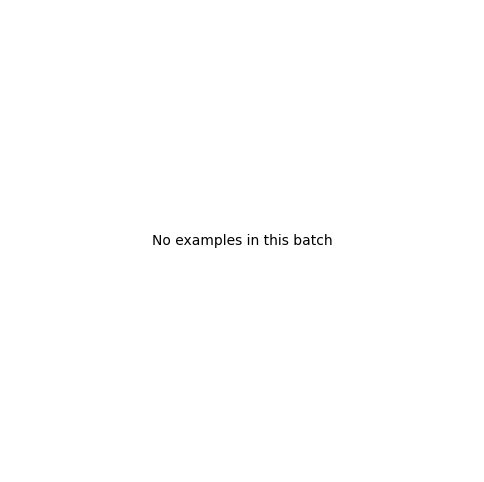

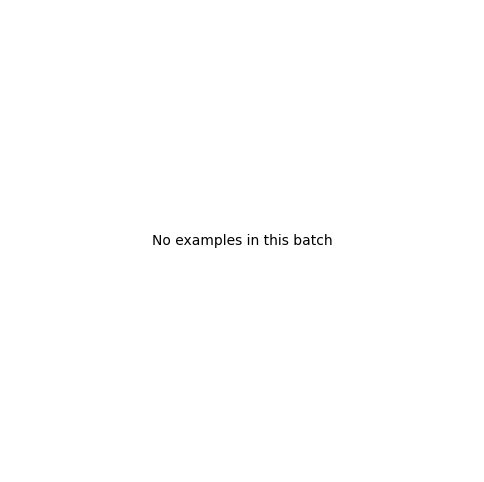

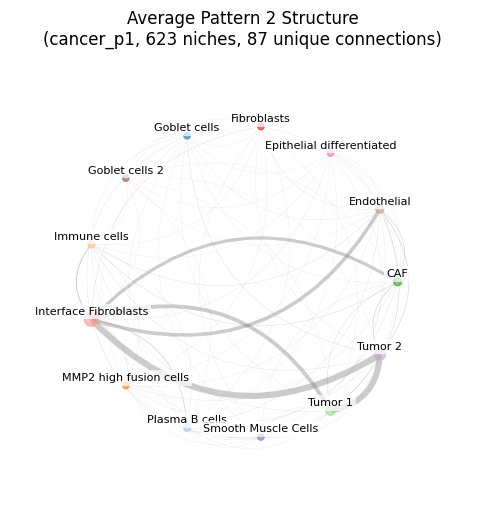

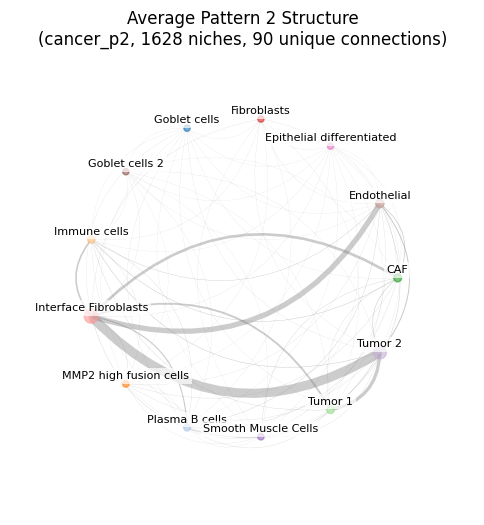

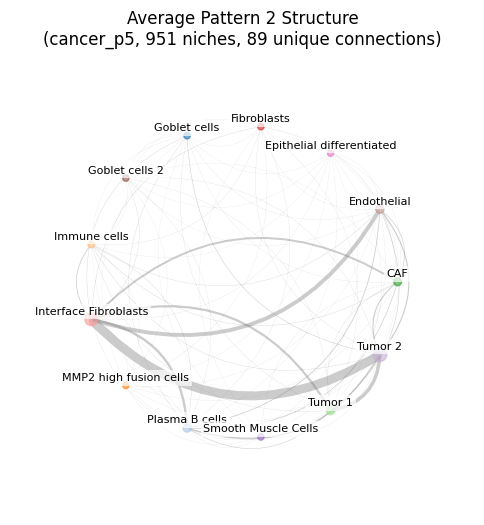

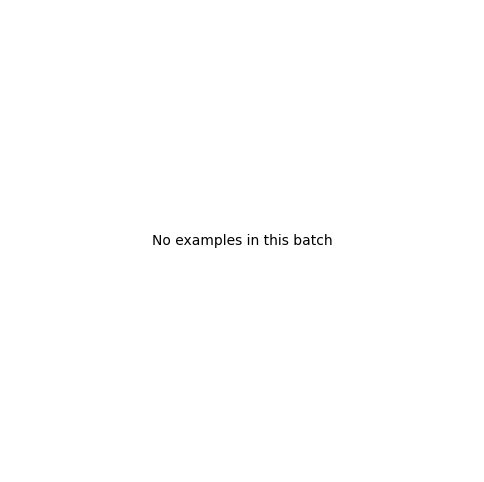

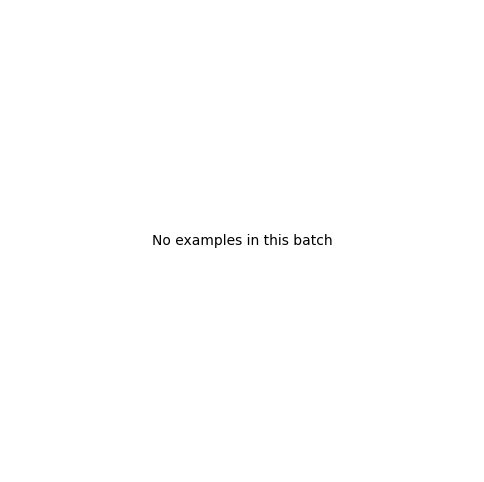

In [25]:
# Export section-specific average graphs to inspect replicate consistency.
for idx in np.unique(niche.clusters):
    for batch in niche.metadata['batch'].unique():
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        niche.get_average_pattern(
            pattern_idx=idx,
            batch_key=batch,
            node_size_range=(20, 100),
            edge_width_range=(0.1, 10),
            edge_curve=0.4,
            return_fig=True,
            ax=ax
        )
        fig.savefig(f'./results/visium-hd/microarc_{idx}_{batch}.pdf', dpi=300)


Save the fitted `MicroArc` object as a checkpoint. This preserves the physically scaled coordinates, 50-micron graph membership, graph-kernel results, and MA assignments used by the communication analysis.


In [11]:
import pickle

with open('./results/visium-hd/microarc_true50um.pkl', 'wb') as handle:
    pickle.dump(niche, handle)


## 5. Map MA assignments back to tissue space

A spot can occur in more than one overlapping local graph. The helper below records each graph's MA assignment on its member spots for downstream summaries. The spatial overview uses the graph centers and tissue background in the same micron coordinate system.


In [27]:
def add_pattern_assignments(adata, niche):
    """Propagate each local graph's MA label to its member cells."""
    if niche.clusters is None:
        raise ValueError("Run compute_kernel_and_cluster first")
    
    adata.obs['niche_pattern'] = 'None'
    
    for i, neighbor_indices in enumerate(niche.neighbor_indices):
        pattern = niche.clusters[i]
        adata.obs.loc[neighbor_indices, 'niche_pattern'] = f'Pattern_{pattern}'
    
    return adata

adata = add_pattern_assignments(adata, niche)

adata.obs.to_csv('./results/visium-hd/metadata_with_patterns.csv')


In [134]:
def plot_spatial_pattern_distribution(niche, metadata, batch_key='batch'):
    """Plot MA graph centers in the coordinate system of each tumor section."""
    import seaborn as sns

    clusters = niche.clusters
    centers = metadata.loc[niche.center_indices]
    batches = metadata[batch_key].unique()
    fig, axes = plt.subplots(1, len(batches), figsize=(6 * len(batches), 4.5))
    axes = np.atleast_1d(axes)

    n_mas = len(np.unique(clusters))
    ma_colors = sns.color_palette('husl', n_mas)

    for panel, sample in enumerate(batches):
        ax = axes[panel]
        sample_spots = metadata[metadata[batch_key] == sample]

        non_tumor = sample_spots.loc[sample_spots['domain'] != 5]
        ax.scatter(
            non_tumor['x'], -non_tumor['y'], c='lightgray', s=0.5,
            alpha=0.1, rasterized=True,
        )
        tumor = sample_spots.loc[sample_spots['domain'] == 5]
        ax.scatter(
            tumor['x'], -tumor['y'], c='lightgray', s=1,
            alpha=0.5, rasterized=True,
        )

        for ma_index in range(n_mas):
            ma_centers = centers.iloc[clusters == ma_index]
            ma_centers = ma_centers.loc[ma_centers.index.isin(sample_spots.index)]
            if ma_centers.empty:
                continue
            ax.scatter(
                ma_centers['x'], -ma_centers['y'],
                c=[ma_colors[ma_index]], s=4, alpha=0.7,
                label=f'MA {ma_index + 1}', rasterized=True,
            )

        ax.set_title(f'{sample} MicroArchitecture Distribution')
        if panel == len(batches) - 1:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_aspect('equal')
        ax.axis('off')

    fig.tight_layout()
    return fig


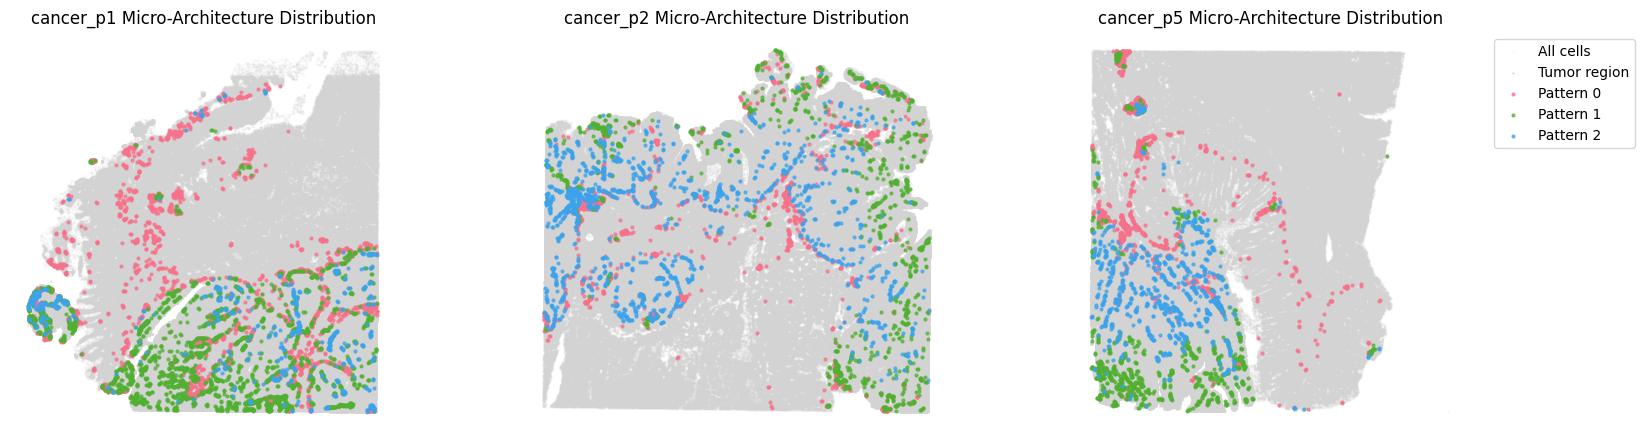

In [135]:
cancer_metadata_um = metadata_um[
    metadata_um['batch'].astype(str).str.startswith('cancer')
]
fig = plot_spatial_pattern_distribution(niche, cancer_metadata_um)
fig


In [137]:
fig.savefig(
    './results/visium-hd/microarc_spatial_dist_tumor_true50um.pdf',
    dpi=300,
    bbox_inches='tight',
)


## 6. Nominal ligand-receptor analysis across CRC microarchitectures

CellPhoneDB is applied separately to the spots represented by each MA. The nominal permutation p-values provide the underlying interaction tables used for the molecular-network, dotplot, and tileplot summaries.


In [ ]:
from liana.method import cellphonedb
import liana as li

with open('./results/visium-hd/microarc_true50um.pkl', 'rb') as handle:
    nominal_niche = pickle.load(handle)


def analyze_nominal_lr_programs(adata, microarc):
    """Run CellPhoneDB on the unique spots represented by each MA."""
    if microarc.clusters is None:
        raise ValueError("Run compute_kernel_and_cluster first")

    ma_adatas = {}

    def collect_spots(graph_indices):
        spot_names = pd.Index(
            np.concatenate([
                microarc.neighbor_indices[index]
                for index in graph_indices
            ])
        ).unique()
        return adata[spot_names].copy()

    for ma_index in range(microarc.n_clusters):
        graph_indices = np.flatnonzero(microarc.clusters == ma_index)
        ma_adata = collect_spots(graph_indices)
        if ma_adata.n_obs < 3:
            raise ValueError(
                f'MicroArchitecture {ma_index + 1} has insufficient spots'
            )

        cellphonedb(
            ma_adata,
            groupby='cell_type',
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True,
            key_added='cpdb_res',
            use_raw=False,
        )
        ma_adatas[f'pattern_{ma_index}'] = ma_adata

    return ma_adatas


pattern_adatas = analyze_nominal_lr_programs(adata, nominal_niche)
cts = [
    'Interface Fibroblasts', 'Immune cells', 'Endothelial',
    'CAF', 'Tumor 1', 'Tumor 2',
]


In [56]:
def plot_molecular_network(
    df,
    positions_obj,
    cell_types=None,
    pval_threshold=0.05,
    node_size_range=(100, 1000),
    edge_width_range=(1, 10),
    edge_curve=0.4,
    cmap=None,
    edge_cmap='YlOrRd',
    figsize=(6, 6),
    global_max_lr=None,
    global_max_edge=None
):
    sig_df = df[df['cellphone_pvals'] < pval_threshold].copy()
    
    if cell_types is not None:
        sig_df = sig_df[
            (sig_df['source'].isin(cell_types)) & 
            (sig_df['target'].isin(cell_types))
        ]
        
        if len(sig_df) == 0:
            raise ValueError("No interactions found between selected cell types")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    if cmap is None:
        import seaborn as sns
        cmap = sns.color_palette('tab20')[:len(positions_obj.global_positions)]
    
    G = nx.DiGraph()
            
    if cell_types is not None:
        all_cells = set(cell_types)
    else:
        all_cells = set(sig_df['source'].unique()) | set(sig_df['target'].unique())
        
    for cell_type in all_cells:
        G.add_node(cell_type)
    
    node_lr_counts = Counter()
    for _, row in sig_df.iterrows():
        node_lr_counts[row['source']] += 1
        node_lr_counts[row['target']] += 1
    
    edge_weights = sig_df.groupby(['source', 'target']).size().to_dict()
    
    for (source, target), weight in edge_weights.items():
        G.add_edge(source, target, weight=weight)
    
    pos = {node: positions_obj.global_positions[node] for node in G.nodes()}
    
    max_count = global_max_lr if global_max_lr is not None else max(node_lr_counts.values()) if node_lr_counts else 1
    node_sizes = {
        node: np.interp(
            node_lr_counts.get(node, 0),
            [0, max_count],
            node_size_range
        )
        for node in G.nodes()
    }
    
    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=[node_sizes[node] for node in G.nodes()],
        node_color=cmap[:len(G.nodes())],
        alpha=0.6,
        ax=ax
    )
    
    if G.edges():
        edge_weights_arr = np.array([G[u][v]["weight"] for u, v in G.edges()])
        
        max_edge = global_max_edge if global_max_edge is not None else max(edge_weights_arr)
        edge_widths = np.interp(
            edge_weights_arr,
            [0, max_edge],
            edge_width_range
        )
        
        edge_pvals = np.array([-np.log10(sig_df.groupby(['source', 'target'])['cellphone_pvals'].mean()[e] + 1e-300) 
                              for e in G.edges()])
        edge_colors = plt.cm.get_cmap(edge_cmap)(
            (edge_pvals - min(edge_pvals)) / (max(edge_pvals) - min(edge_pvals))
        )
        
        for (node1, node2), width, color in zip(G.edges(), edge_widths, edge_colors):
            pos1 = pos[node1]
            pos2 = pos[node2]
            
            connection = patches.ConnectionStyle.Arc3(rad=edge_curve)
            edge_patch = patches.FancyArrowPatch(
                pos1,
                pos2,
                connectionstyle=connection,
                arrowstyle='-|>',
                linewidth=width,
                alpha=0.6,
                color=color,
                mutation_scale=20,
                shrinkB=10,
                zorder=1
            )
            ax.add_patch(edge_patch)
        
        sm = plt.cm.ScalarMappable(
            cmap=plt.cm.get_cmap(edge_cmap),
            norm=plt.Normalize(vmin=min(edge_pvals), vmax=max(edge_pvals))
        )
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label('-log10(p-value)')
    
    label_pos = {node: (coord[0], coord[1] + 0.05) 
                for node, coord in pos.items()}
    nx.draw_networkx_labels(
        G,
        label_pos,
        ax=ax,
        font_size=8,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
    )
    
    ax.set_title(
        "Molecular Communication Network\n"
        "(Edge width: number of L-R pairs, Edge color: significance)",
        pad=20
    )
    ax.margins(x=0.2, y=0.2)
    ax.axis('off')
    
    return fig, ax, G

### 6.1 Molecular communication networks

Node size is the number of retained ligand-receptor pairs involving a cell type, edge width is the number of pairs for a source-target direction, and edge color represents nominal p-value significance. The panels are ordered from MA 1 to MA 3.


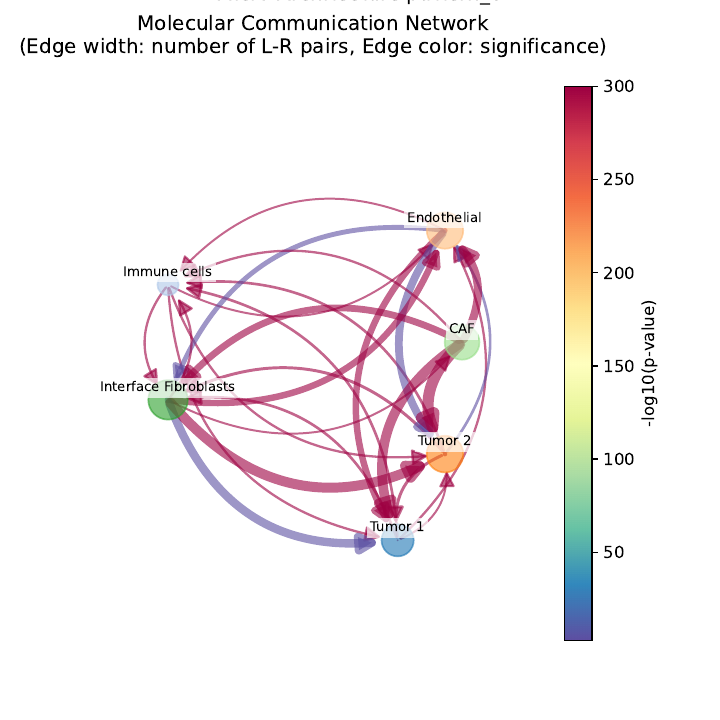

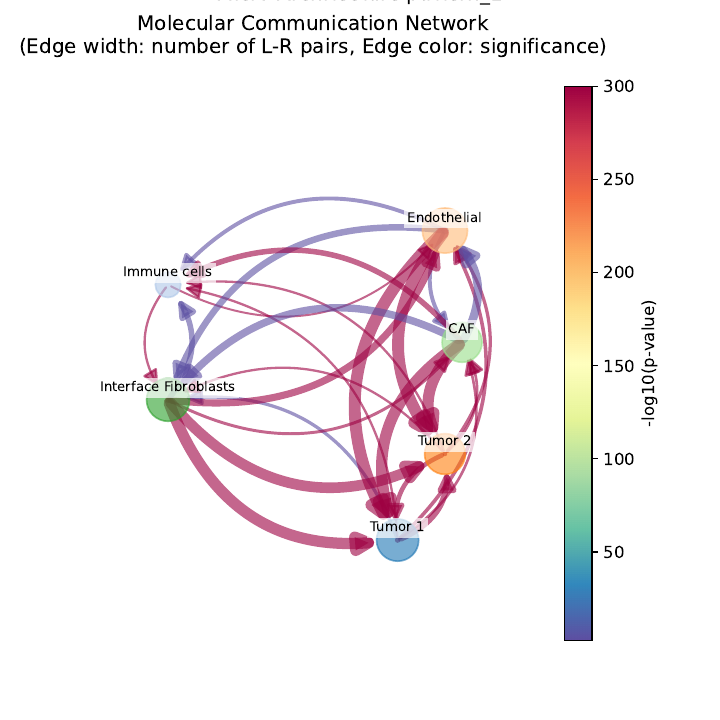

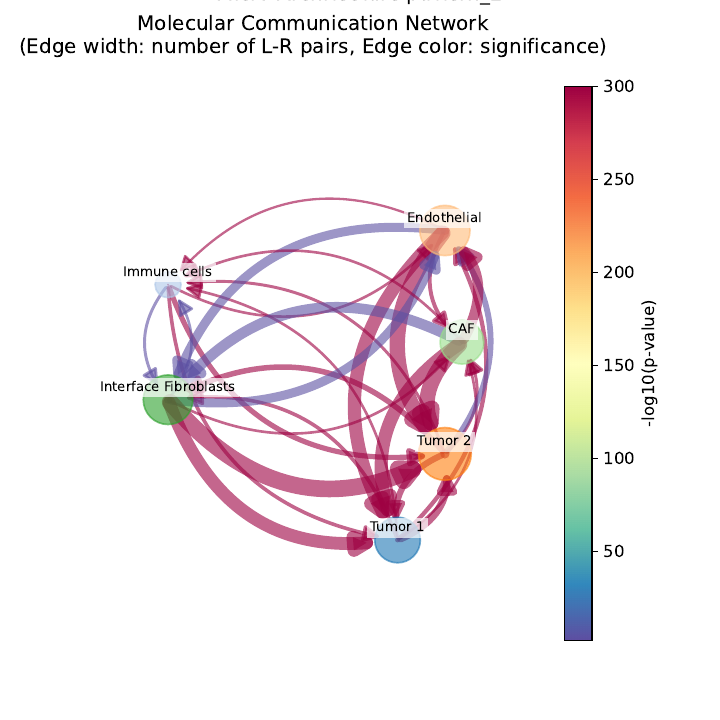

In [61]:
global_max_lr_pairs = 0
global_max_edge_pairs = 0

for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    if pattern_adata.uns['cpdb_res'].empty:
        continue
    
    df = pattern_adata.uns['cpdb_res']
    sig_df = df[df['cellphone_pvals'] < 0.05]
    
    sig_df = sig_df[
        (sig_df['source'].isin(cts)) & 
        (sig_df['target'].isin(cts))
    ]
    
    lr_counts = pd.concat([sig_df['source'], sig_df['target']]).value_counts()
    global_max_lr_pairs = max(global_max_lr_pairs, lr_counts.max() if len(lr_counts) > 0 else 0)
    
    edge_counts = sig_df.groupby(['source', 'target']).size()
    global_max_edge_pairs = max(global_max_edge_pairs, edge_counts.max() if len(edge_counts) > 0 else 0)

for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    if pattern_adata.uns['cpdb_res'].empty:
        continue
        
    fig, ax, G = plot_molecular_network(
        pattern_adata.uns['cpdb_res'], 
        nominal_niche,
        cell_types=cts,
        pval_threshold=0.05,
        edge_cmap='Spectral_r',
        node_size_range=(100, 1000),
        edge_width_range=(1, 10),
        edge_curve=0.4,
        global_max_lr=global_max_lr_pairs,
        global_max_edge=global_max_edge_pairs
    )
    
    plt.suptitle(f"Micro-Architecture {pattern}", y=1.02)
    plt.savefig(f"./results/visium-hd/microarc_mole_{pattern}.pdf", dpi=300)
    plt.show()

In [60]:
for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    if pattern_adata.uns['cpdb_res'].empty:
        continue
    pattern_adata.uns['cpdb_res'].to_csv(f"./results/visium-hd/cpdb_microarc_mole_{pattern}.csv")

### 6.2 Nominal-p tileplots

Each panel shows the top 20 CellPhoneDB interactions for one MA, ordered by nominal permutation p-value. The panels are ordered from MA 1 to MA 3.


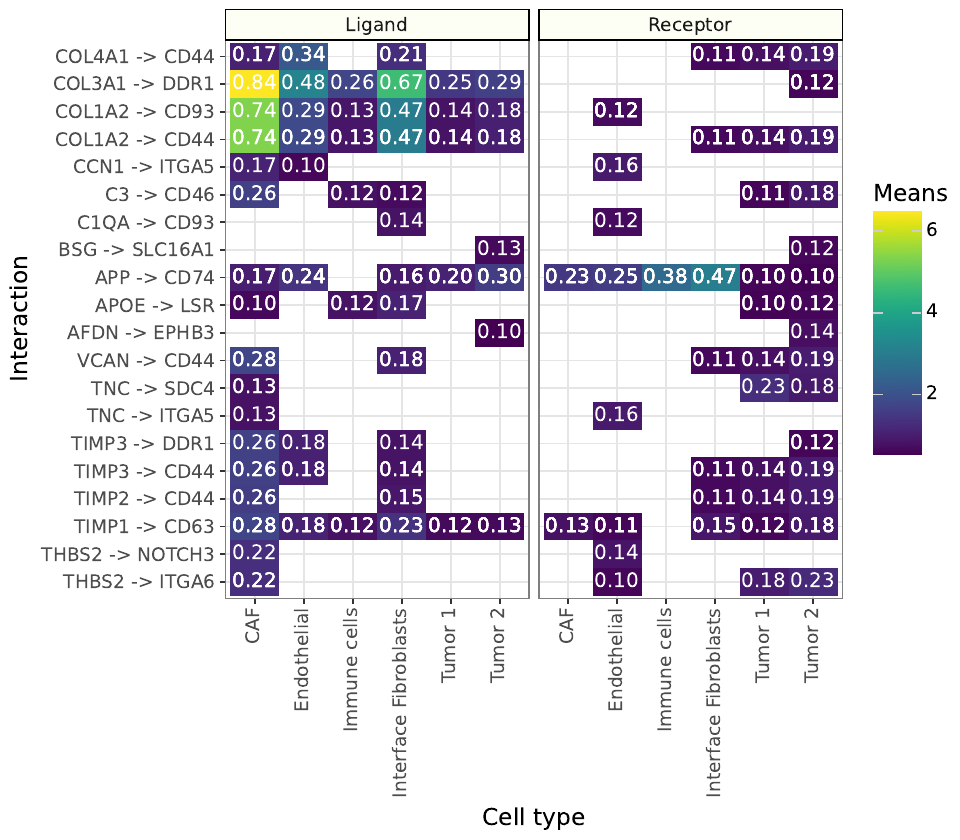

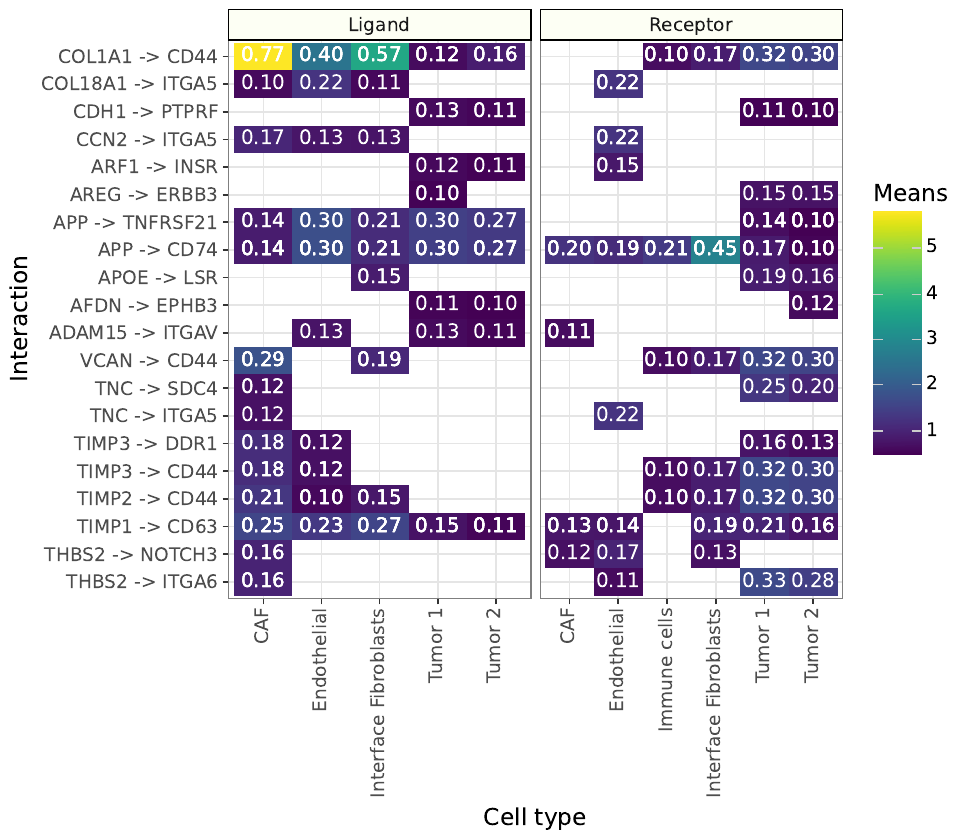

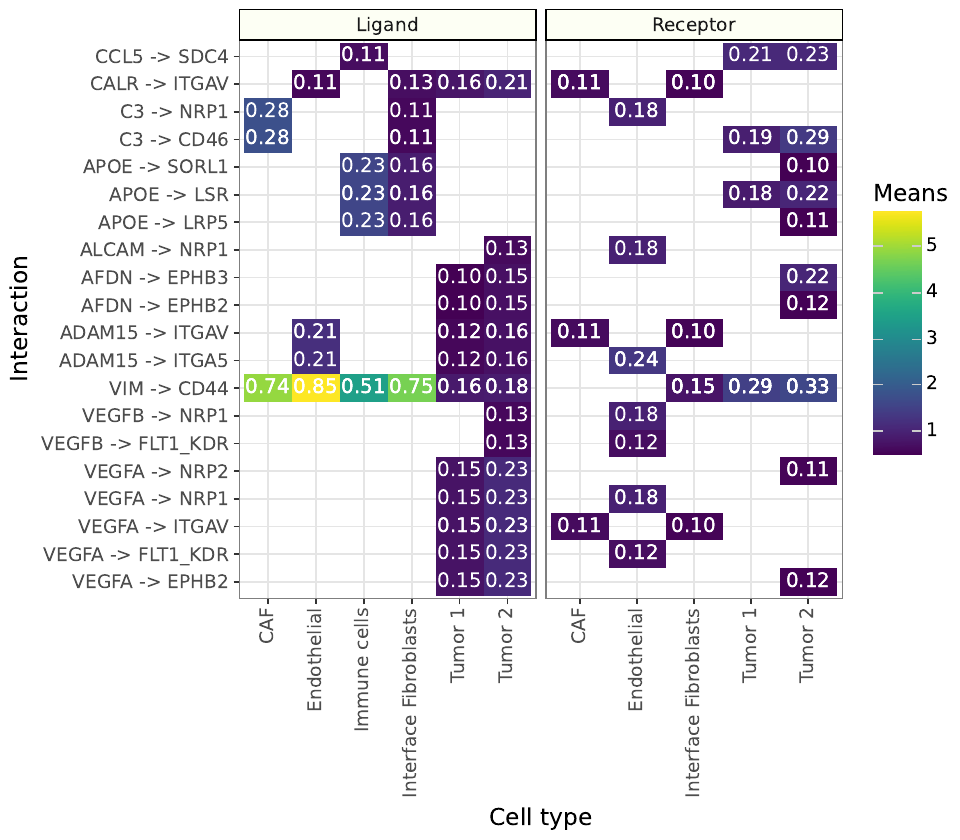

In [64]:
import plotnine as pn
from IPython.display import display

cts = ['Interface Fibroblasts', 'Immune cells', 'Endothelial', 'CAF', 'Tumor 1', 'Tumor 2']
for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    if pattern_adata.uns['cpdb_res'].empty:
        continue    
    fig = li.pl.tileplot(adata = pattern_adata,
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=20,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=cts,
                         target_labels=cts,
                         uns_key='cpdb_res',
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
    fig.save(f"./results/visium-hd/cpdb_microarc_{pattern}_tileplot.pdf")
    display(fig)

### 6.3 Nominal-p dotplots

Dot size represents the nominal CellPhoneDB permutation p-value and dot color represents the ligand-receptor mean. The panels are ordered from MA 1 to MA 3.


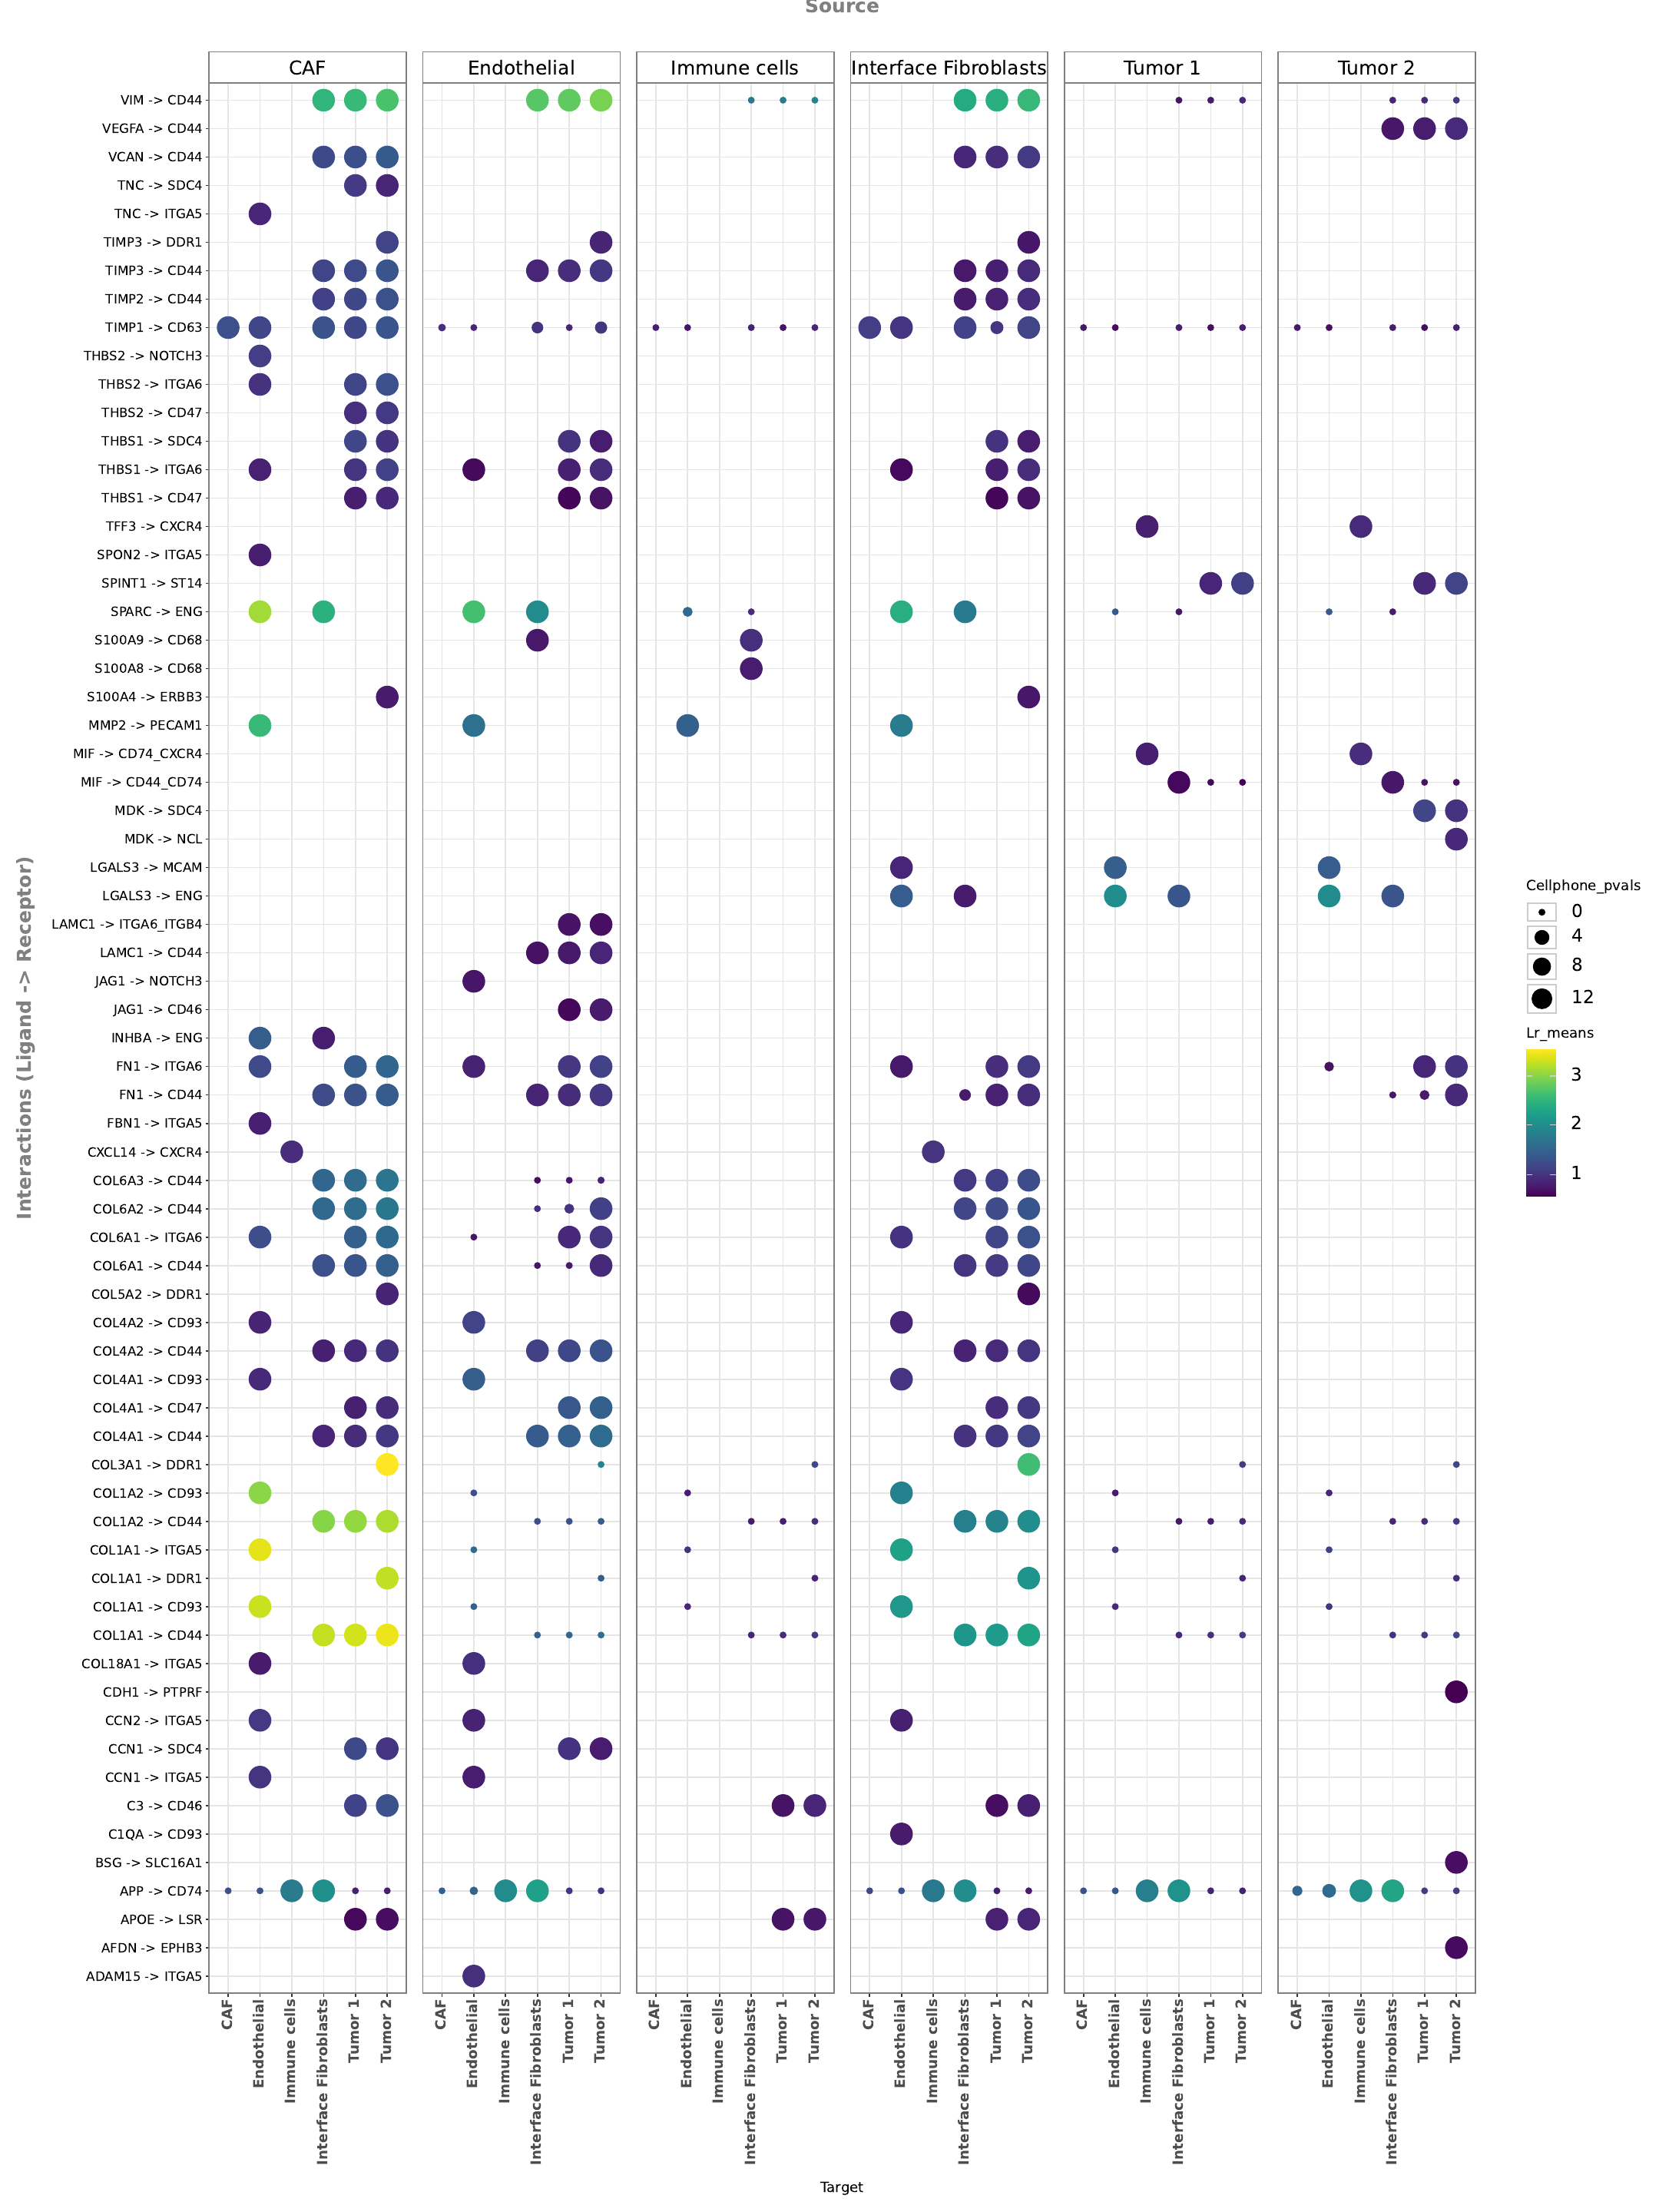

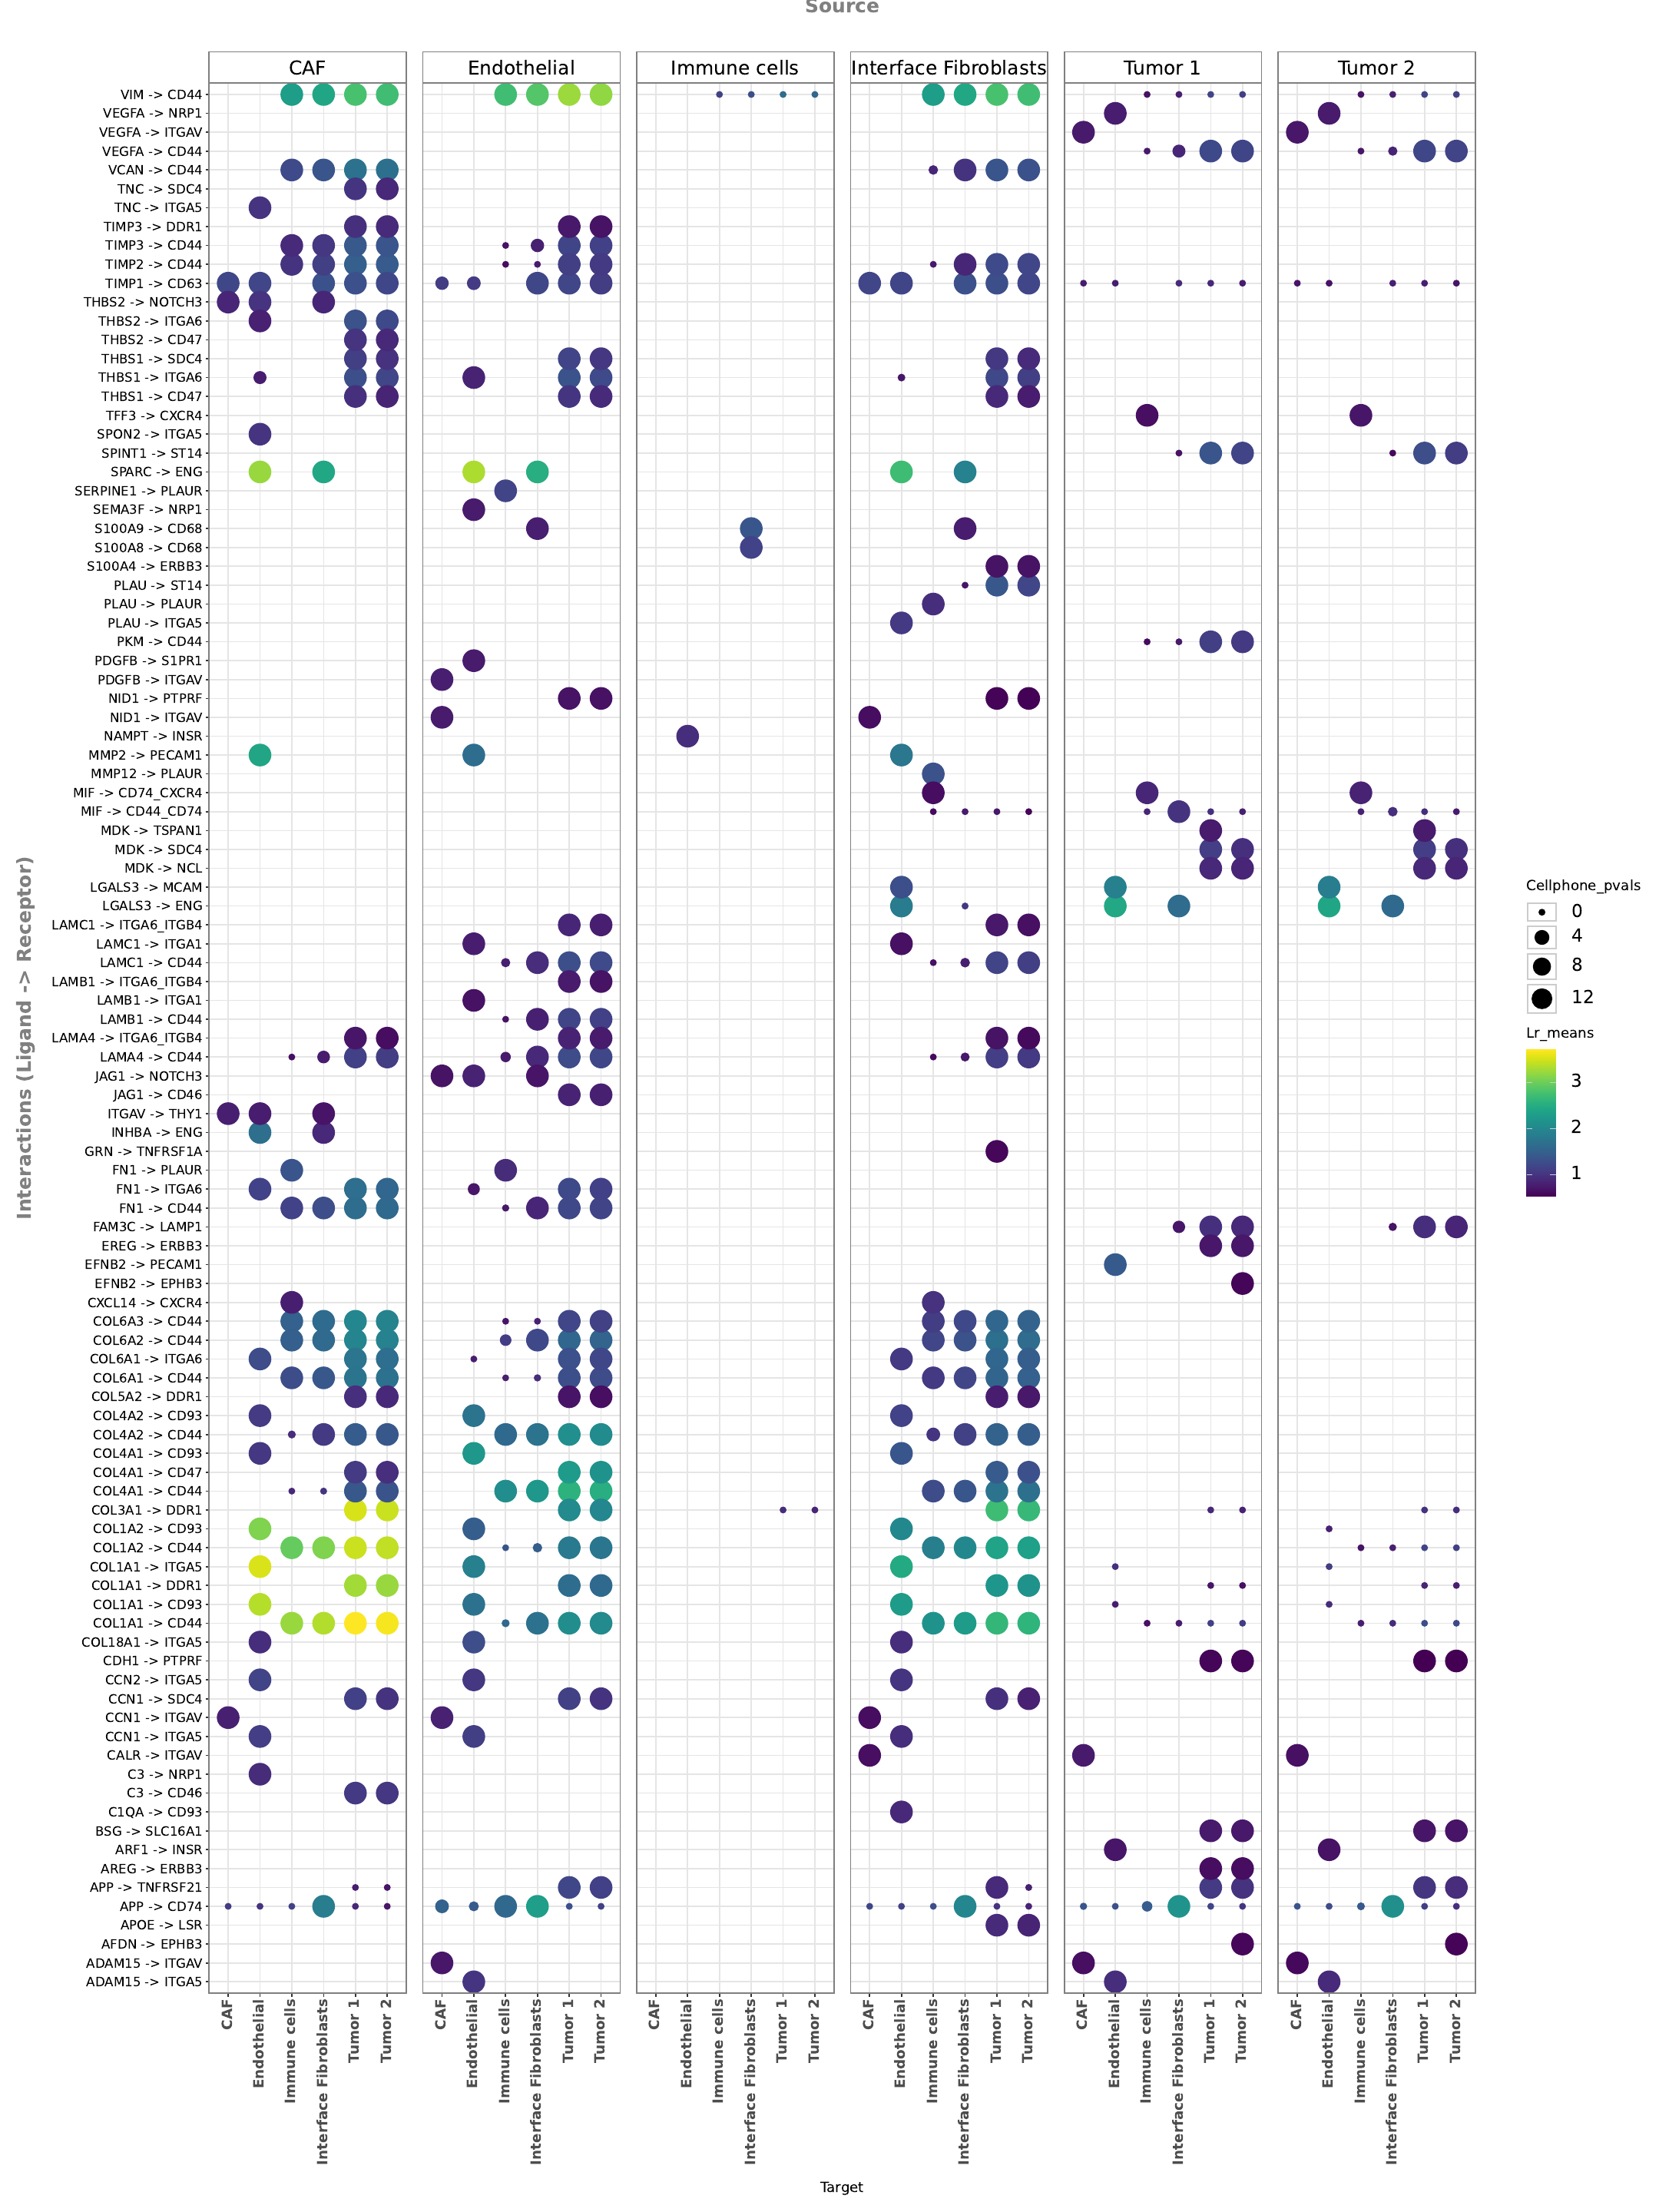

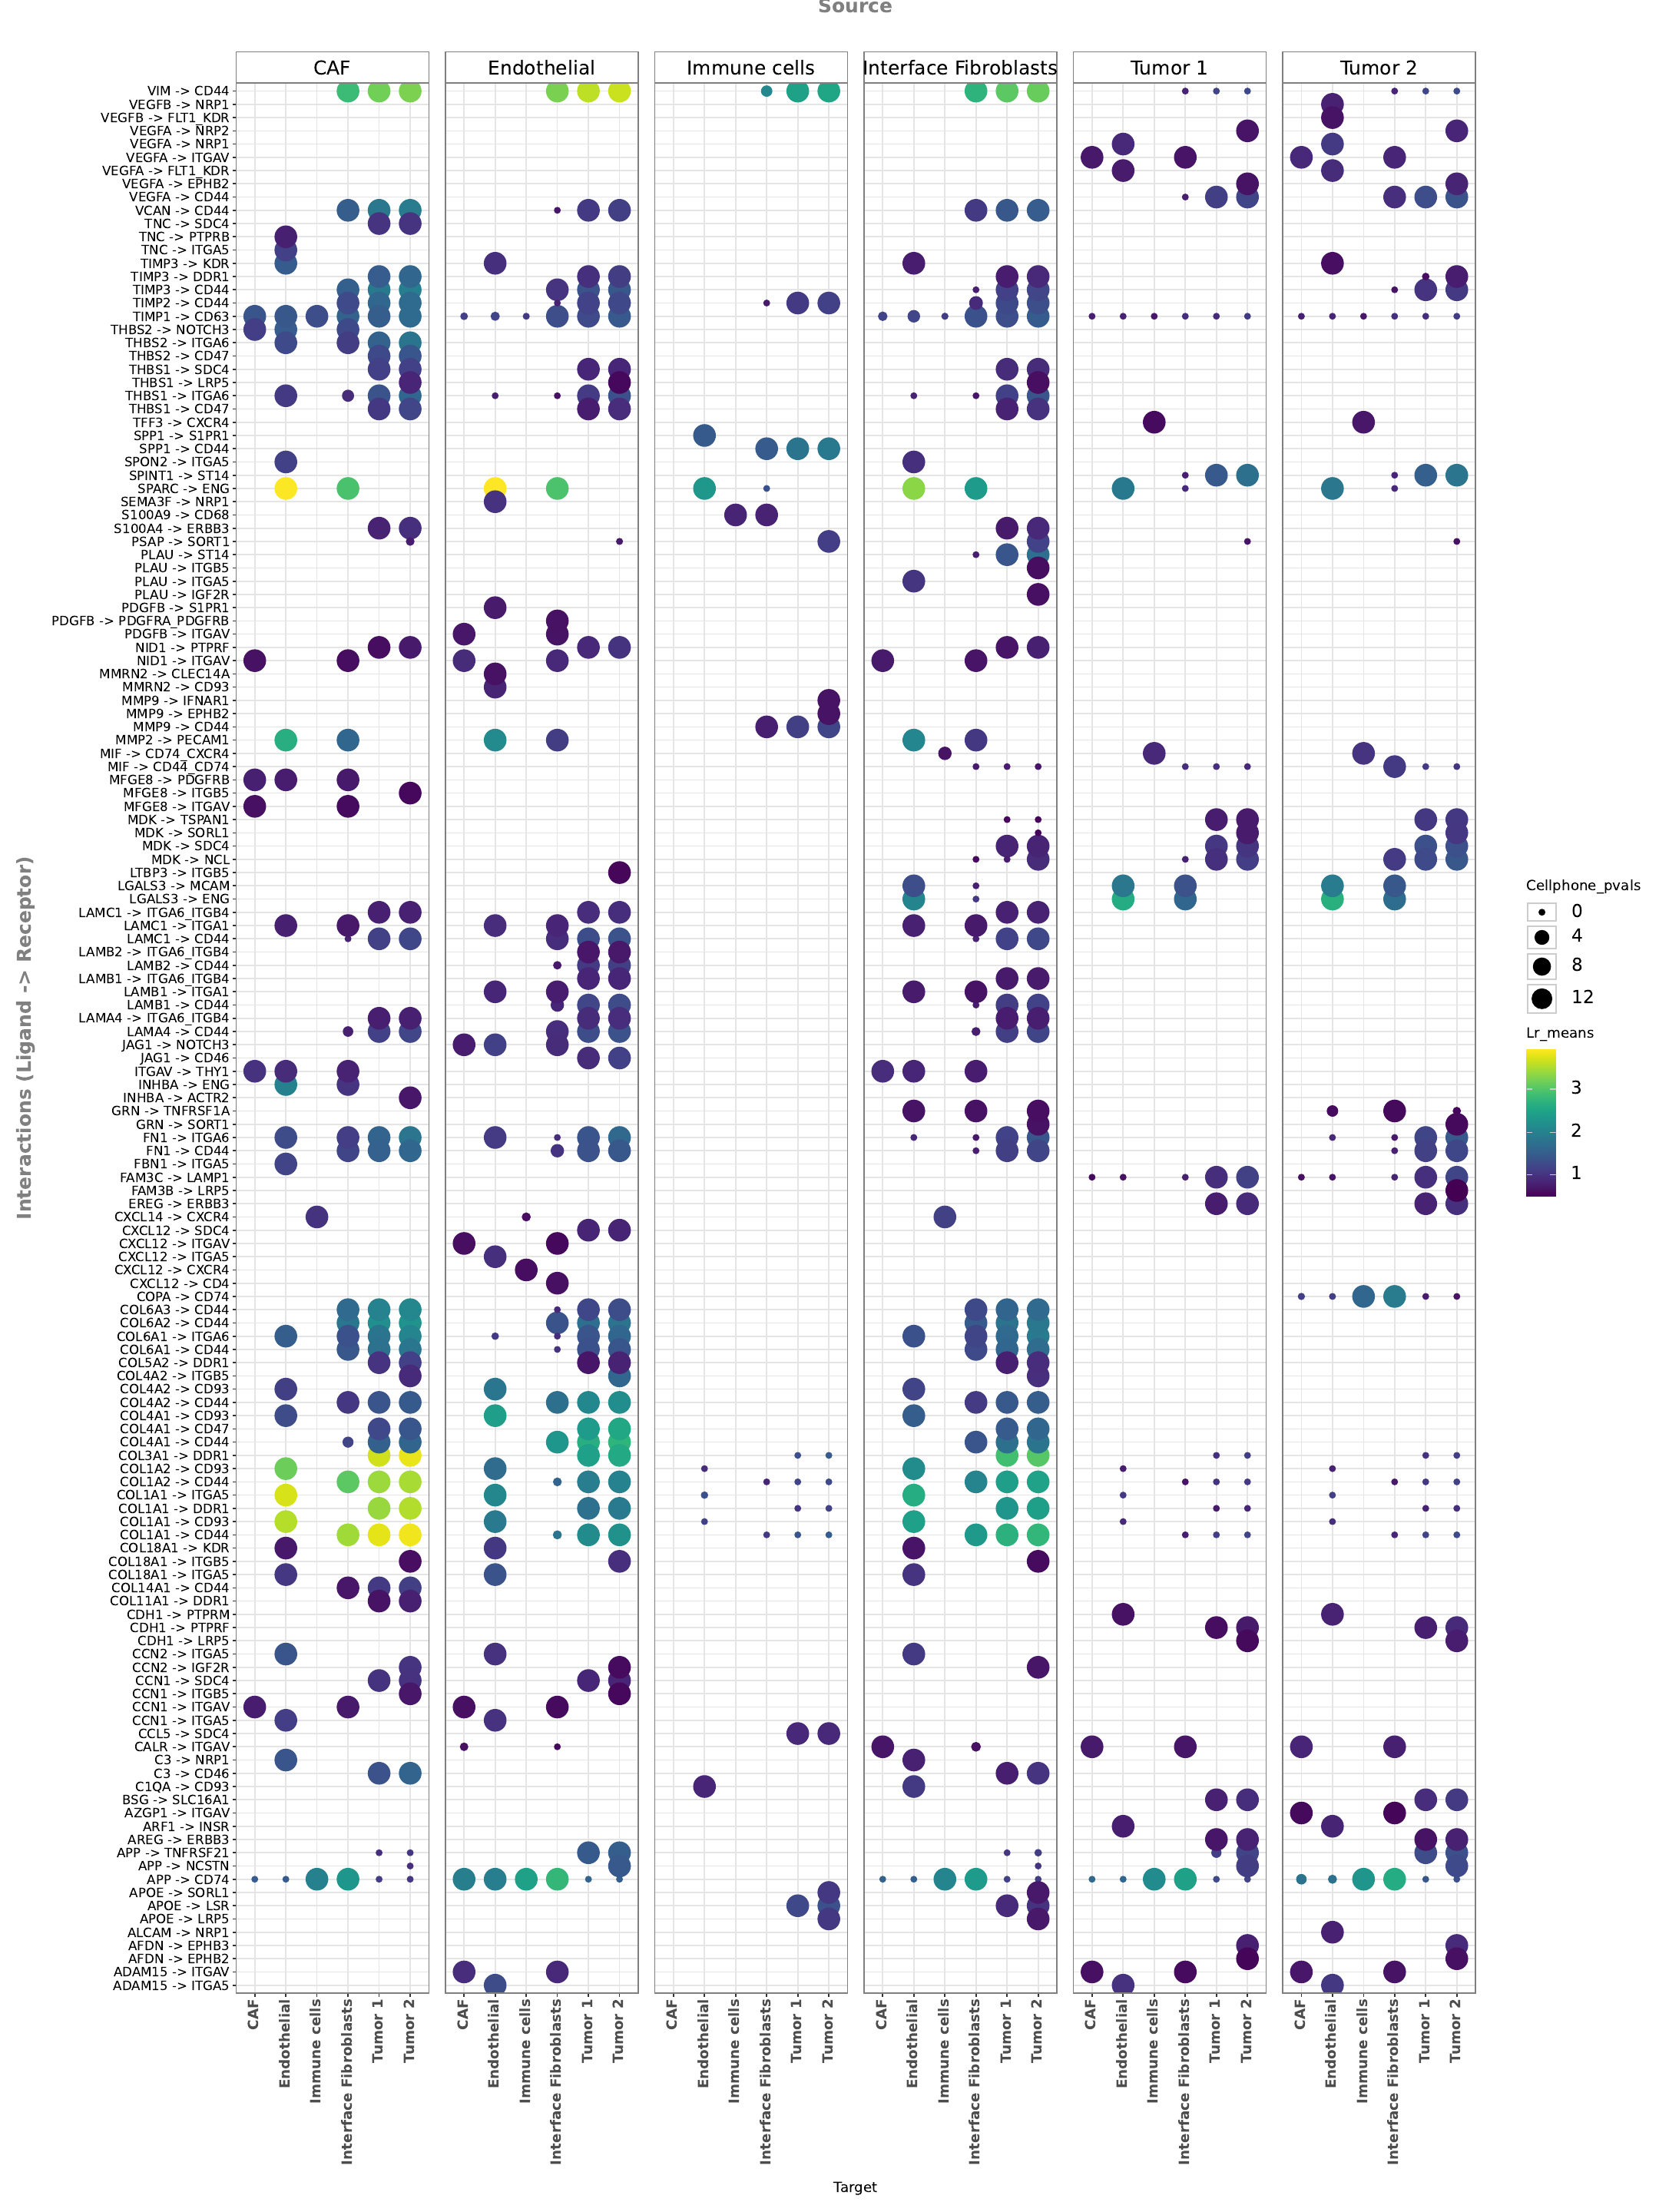

In [65]:
from IPython.display import display

cts = ['Interface Fibroblasts', 'Immune cells', 'Endothelial', 'CAF', 'Tumor 1', 'Tumor 2']
for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    if pattern_adata.uns['cpdb_res'].empty:
        continue
    fig = li.pl.dotplot(adata = pattern_adata,
                  colour='lr_means',
                  size='cellphone_pvals',
                  inverse_size=True, # we inverse sign since we want small p-values to have large sizes
                  # source_labels=['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                  # target_labels=['CD34+', 'CD56+ NK'],
                  source_labels=cts,
                  target_labels=cts,
                  figure_size=(18, 24), 
                  filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
                  uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
                 )
    fig.save(f"./results/visium-hd/cpdb_microarc_{pattern}_dotplot.pdf")
    display(fig)


## 7. BH-FDR post-processing for CRC ligand-receptor figures

For each MA, the union of spots from all member graphs is analyzed once, so overlapping local graphs do not duplicate spots within that MA. CellPhoneDB estimates ligand-receptor activity by cell type. Benjamini-Hochberg correction is applied independently to the complete CellPhoneDB result table from each MA. The corrected tables are used for the molecular networks and the MA-specific dotplots and tileplots.


In [ ]:
from liana.method import cellphonedb
import liana as li

lr_output_dir = Path('./results/visium-hd/lr-analyses-true50um')
lr_output_dir.mkdir(parents=True, exist_ok=True)


def collect_ma_expression(adata, niche, ma_index):
    """Return unique spots represented by all local graphs in one MA."""
    graph_indices = np.flatnonzero(niche.clusters == ma_index)
    spot_names = pd.Index(
        np.concatenate([niche.neighbor_indices[index] for index in graph_indices])
    ).unique()
    missing = spot_names.difference(adata.obs_names)
    if len(missing):
        raise ValueError(f'MA {ma_index + 1} has {len(missing)} unmatched spots')
    return adata[spot_names].copy()


def add_bh_fdr(frame, p_column='cellphone_pvals', output_column='bh_fdr'):
    """Apply Benjamini-Hochberg correction to all finite p-values in a table."""
    result = frame.copy()
    p_values = pd.to_numeric(result[p_column], errors='coerce').to_numpy(float)
    adjusted = np.full(p_values.shape, np.nan, dtype=float)
    valid_indices = np.flatnonzero(np.isfinite(p_values))
    if len(valid_indices):
        order = valid_indices[np.argsort(p_values[valid_indices])]
        ranked = p_values[order]
        ranks = np.arange(1, len(order) + 1)
        ranked_adjusted = ranked * len(order) / ranks
        ranked_adjusted = np.minimum.accumulate(ranked_adjusted[::-1])[::-1]
        adjusted[order] = np.clip(ranked_adjusted, 0.0, 1.0)
    result[output_column] = adjusted
    return result


In [ ]:
ma_cpdb = {}
for ma_index in range(niche.n_clusters):
    ma_name = f'MA_{ma_index + 1}'
    ma_adata = collect_ma_expression(adata, niche, ma_index)
    if ma_adata.n_obs < 3:
        raise ValueError(f'{ma_name} has insufficient spots for CellPhoneDB')

    cellphonedb(
        ma_adata,
        groupby='cell_type',
        resource_name='consensus',
        expr_prop=0.1,
        key_added='cpdb_res',
        use_raw=False,
        verbose=True,
    )
    ma_adata.uns['cpdb_res'] = add_bh_fdr(ma_adata.uns['cpdb_res'])
    ma_adata.uns['cpdb_res'].to_csv(
        lr_output_dir / f'niche_pattern_{ma_index}_cellphonedb_bh_fdr.csv',
        index=False,
    )
    ma_cpdb[ma_name] = ma_adata


### 7.1 BH-FDR dotplots and tileplots

Dot size represents the BH-FDR-adjusted CellPhoneDB permutation p-value and dot color represents the ligand-receptor mean. Tileplots show the top 20 interactions ranked by BH-FDR, with labels indicating the expression-proportion criterion.


In [ ]:
crc_cell_types = [
    'Interface Fibroblasts', 'Immune cells', 'Endothelial',
    'CAF', 'Tumor 1', 'Tumor 2',
]

for ma_index, ma_adata in enumerate(ma_cpdb.values()):
    result = ma_adata.uns['cpdb_res']
    present_sources = [x for x in crc_cell_types if x in set(result['source'])]
    present_targets = [x for x in crc_cell_types if x in set(result['target'])]

    dotplot = li.pl.dotplot(
        liana_res=result,
        colour='lr_means',
        size='bh_fdr',
        inverse_size=True,
        source_labels=present_sources,
        target_labels=present_targets,
        filter_fun=lambda frame: frame['bh_fdr'] <= 0.05,
        figure_size=(18, 24),
    )
    dotplot.save(
        lr_output_dir / f'cpdb_microarc_pattern_{ma_index}_dotplot.pdf',
        verbose=False,
    )

    tileplot = li.pl.tileplot(
        liana_res=result,
        fill='means',
        label='props',
        label_fun=lambda value: '*' if value >= 0.5 else np.nan,
        top_n=20,
        orderby='bh_fdr',
        orderby_ascending=True,
        source_labels=present_sources,
        target_labels=present_targets,
        source_title='Ligand',
        target_title='Receptor',
        figure_size=(8, 7),
    )
    tileplot.save(
        lr_output_dir / f'cpdb_microarc_pattern_{ma_index}_tileplot.pdf',
        verbose=False,
    )


### 7.2 BH-FDR molecular communication networks

Each network retains ligand-receptor pairs with BH-FDR below 0.05 among the six CRC cell types used in the MA interpretation. Node size is the number of retained pairs involving that cell type, edge width is the number of retained pairs for that source-target direction, and edge color is the mean BH-FDR significance for that direction. All three MAs share node, edge, and color scales.


In [ ]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


def prepare_ma_network(result, cell_types, threshold=0.05):
    retained = result[
        result['bh_fdr'].lt(threshold)
        & result['source'].isin(cell_types)
        & result['target'].isin(cell_types)
    ].copy()
    edge_summary = (
        retained.groupby(['source', 'target'])
        .agg(pair_count=('bh_fdr', 'size'), mean_bh_fdr=('bh_fdr', 'mean'))
        .reset_index()
    )
    node_counts = pd.concat([retained['source'], retained['target']]).value_counts()
    return retained, edge_summary, node_counts


network_data = {
    name: prepare_ma_network(ma_adata.uns['cpdb_res'], crc_cell_types)
    for name, ma_adata in ma_cpdb.items()
}
max_node_count = max(
    (counts.max() for _, _, counts in network_data.values() if len(counts)),
    default=1,
)
max_edge_count = max(
    (edges['pair_count'].max() for _, edges, _ in network_data.values() if len(edges)),
    default=1,
)
edge_score_arrays = [
    -np.log10(edges['mean_bh_fdr'].to_numpy() + 1e-300)
    for _, edges, _ in network_data.values() if len(edges)
]
all_edge_scores = (
    np.concatenate(edge_score_arrays) if edge_score_arrays else np.array([])
)
score_min = float(all_edge_scores.min()) if len(all_edge_scores) else 0.0
score_max = float(all_edge_scores.max()) if len(all_edge_scores) else 1.0
if score_max <= score_min:
    score_max = score_min + 1.0
score_norm = Normalize(vmin=score_min, vmax=score_max)

all_cell_types = sorted(niche.global_positions)
node_colors = dict(zip(all_cell_types, plt.cm.tab20(np.linspace(0, 1, len(all_cell_types)))))
fig, axes = plt.subplots(1, niche.n_clusters, figsize=(18, 6))
axes = np.atleast_1d(axes)

for ma_index, (ma_name, (_, edges, node_counts)) in enumerate(network_data.items()):
    ax = axes[ma_index]
    graph = nx.DiGraph()
    graph.add_nodes_from(crc_cell_types)
    for row in edges.itertuples(index=False):
        graph.add_edge(
            row.source,
            row.target,
            pair_count=row.pair_count,
            mean_bh_fdr=row.mean_bh_fdr,
        )

    positions = {node: niche.global_positions[node] for node in graph.nodes}
    sizes = [
        np.interp(node_counts.get(node, 0), [0, max_node_count], [100, 1000])
        for node in graph.nodes
    ]
    nx.draw_networkx_nodes(
        graph, positions, ax=ax, node_size=sizes,
        node_color=[node_colors[node] for node in graph.nodes], alpha=0.7,
    )

    for source, target, attributes in graph.edges(data=True):
        width = np.interp(attributes['pair_count'], [0, max_edge_count], [1, 10])
        score = -np.log10(attributes['mean_bh_fdr'] + 1e-300)
        arrow = patches.FancyArrowPatch(
            positions[source], positions[target],
            connectionstyle=patches.ConnectionStyle.Arc3(rad=0.4),
            arrowstyle='-|>', linewidth=width, alpha=0.65,
            color=plt.cm.Spectral_r(score_norm(score)),
            mutation_scale=20, shrinkA=10, shrinkB=10, zorder=1,
        )
        ax.add_patch(arrow)

    label_positions = {
        node: (position[0], position[1] + 0.05)
        for node, position in positions.items()
    }
    nx.draw_networkx_labels(
        graph, label_positions, ax=ax, font_size=8,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2),
    )
    ax.set_title(f'MicroArchitecture {ma_index + 1}', fontsize=14, pad=18)
    ax.margins(x=0.2, y=0.2)
    ax.axis('off')

colorbar = fig.colorbar(
    ScalarMappable(norm=score_norm, cmap='Spectral_r'),
    ax=axes, orientation='horizontal', fraction=0.05, pad=0.12, shrink=0.45,
)
colorbar.set_label('-log10(BH-FDR)')
fig.savefig(
    lr_output_dir / 'microarc_mole_patterns_bh_fdr_stacked.pdf',
    bbox_inches='tight',
)
fig.savefig(
    lr_output_dir / 'microarc_mole_patterns_bh_fdr_stacked.png',
    dpi=300,
    bbox_inches='tight',
)
plt.show()
